# 16 - Conformal Operators

This notebook is a standalone, executable replacement for Chapter 16 of *Geometric Algebra for Computer Science*. It is original study material written in the same seed-notebook style as the opening chapter: short conceptual moves, reusable helper code, visual artifacts, and sanity checks that can be re-run after changing the inputs.

Source verification note: the task asks for printed pages 465-496. Using `pdftotext` on the supplied PDF, printed page 465 starts on PDF page 492. The extractable Chapter 16 text continues through PDF page 522, whose visible page number is 495; PDF page 523 begins Chapter 17 on printed page 497. I therefore treated PDF pages 492-522 as the Chapter 16 content span and inspected PDF page 523 as the upper boundary. The explanations below are curated and paraphrased rather than copied from the textbook.


## The Chapter Idea

The previous conformal-model chapters gave us points, spheres, planes, circles, lines, incidence tests, and Euclidean motions. Chapter 16 changes the emphasis. Instead of asking only what objects live in the model, it asks what new operators become available once spheres and the two null directions are allowed to participate as versor factors.

The central surprise is that reflection in a sphere is not an odd special case. It is the basic inversion operation. Once inversion is accepted as a first-class conformal transformation, uniform scaling, translated scalings, transversions, spiral-like motions, and non-Euclidean model interpretations all fit into the same operational grammar. A Euclidean motion preserves the point at infinity. A more general conformal operator may move or rescale that infinity direction while still preserving angles locally. That is why a straight line can become a circle, why a grid can bend without losing local orthogonality, and why changing the vector that plays the role of infinity can turn the same algebra into a hyperbolic or spherical model.

This notebook uses a deliberately small numerical model. We do not implement a full multivector algebra here. Instead we keep the conformal point embedding, the metric matrix, and the Euclidean formulas that are easiest to inspect. The visuals use two-dimensional cross-sections when that makes the operator visible, and a three-dimensional sphere or torus when the orbit really wants a spatial picture. Every major concept gets either an executable plot, a numerical invariant check, or both.


## Translation Guide

| Geometric idea | Full conformal-algebra style | Notebook representation |
|---|---|---|
| Finite point | Null vector `X = x + no + 0.5 |x|^2 ni` | A 4-vector `[x, y, no, ni]` in a 2-D conformal slice |
| Spherical reflection | Sandwiching by a dual sphere vector | Circle inversion formula `c + r^2 (x-c)/|x-c|^2` |
| Positive scaling | A boost in the `no, ni` plane | A metric-preserving matrix that changes point weight |
| Translation | A translator that fixes infinity | A conformal matrix for `x -> x + t` |
| Noncommutativity | Operator products depend on order | Compare `S T` with `T S` on the same polygon |
| Loxodrome | A conformal rotor with spiraling action | Logarithmic spiral plus inverse stereographic projection |
| Conformal orbit | Repeated action of one operator | Iterated circles and a circular orbit that sweeps a torus |
| Hyperbolic model | Preserve a real unit sphere as infinity | Poincare disk geodesics: circles orthogonal to the boundary |
| Spherical model | Preserve an imaginary unit sphere as infinity | Stereographic great circles: circles meeting the unit circle antipodally |

The goal is not to replace the algebraic notation with coordinates forever. The goal is to make the operator behavior visible enough that the algebraic notation has something concrete to refer to.


## Notebook Route

1. Import the reusable helper module and set the artifact directories.
2. Rebuild the local conformal point bookkeeping: null points, distances, translations, rotations, and scalings.
3. Visualize inversion as spherical reflection and check angle preservation, involution, and line-to-circle behavior.
4. Work through scaling, translation, and their noncommutativity with conformal matrices.
5. Generate loxodromes from logarithmic spirals and verify the constant-bearing property on the sphere.
6. Build conformal orbits: an iterated similarity trail and a circular orbit that sweeps a torus.
7. Compare hyperbolic and spherical model interpretations by changing the geometric role of infinity.
8. Finish with sanity checks and artifact-existence assertions.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Find the project root even if this notebook is opened from the chapter folder.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "utils" / "chapter16_conformal_operators.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find utils/chapter16_conformal_operators.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.chapter16_conformal_operators import (
    Circle2D,
    apply_conformal_matrix,
    circle_arc_inside_disk,
    circle_residual,
    conformal_norm2,
    conformal_point,
    distance_squared_from_inner,
    fit_circle,
    grid_segments,
    invert_points,
    inversion_jacobian,
    inverse_stereographic,
    iterate_similarity,
    line_points,
    loxodrome_bearing_angles,
    loxodrome_plane,
    loxodrome_sphere,
    metric_error,
    poincare_distance,
    poincare_geodesic_circle,
    poincare_radial_points,
    rotation_matrix,
    safe_invert_segments,
    sanity_checks,
    scaling_matrix,
    sphere_mesh,
    spherical_geodesic_circle,
    torus_mesh,
    torus_orbit_circles,
    torus_residual,
    translation_matrix,
    transversion_points,
)

np.set_printoptions(precision=4, suppress=True)

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "chapter-16"
PLOT_DIR = ARTIFACT_DIR / "plots"
DATA_DIR = ARTIFACT_DIR / "data"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

artifact_paths: dict[str, Path] = {}
source_span = {
    "printed_pages_requested": "465-496",
    "pdf_pages_used_for_extractable_chapter_text": "492-522",
    "upper_boundary_checked": "PDF page 523 begins Chapter 17 on printed page 497",
}
print(json.dumps(source_span, indent=2))
print(f"Artifacts will be written under: {ARTIFACT_DIR.relative_to(PROJECT_ROOT)}")


{
  "printed_pages_requested": "465-496",
  "pdf_pages_used_for_extractable_chapter_text": "492-522",
  "upper_boundary_checked": "PDF page 523 begins Chapter 17 on printed page 497"
}
Artifacts will be written under: artifacts\chapter-16


## Reading Operator Products

The notebook repeatedly uses the same interpretation pattern. A simple Euclidean formula is shown first because it lets us see what happens to points, grids, circles, and sampled orbits. Then an invariant is checked because conformal geometry is not just a visual style. It has promises: null point representatives stay null, distances can be recovered from the inner product when the points are normalized, local angles survive inversion and transversion, and object families such as lines and circles remain within the extended round family.

It is also useful to separate three levels of description. At the coordinate level, a transformation is a function on arrays of points. At the conformal-vector level, a transformation is a linear map that preserves the model metric, perhaps changing the point weight before recovery. At the full geometric-algebra level, the same operation is a sandwich product by a versor or rotor. Chapter 16 is powerful because these levels agree. The coordinate formula makes a picture, the matrix check explains why the embedding is legitimate, and the versor view says the operation acts covariantly on every object, not just on individual point samples.

Order matters throughout the chapter. The product that means translate-then-scale is not the product that means scale-then-translate. Inversion-translation-inversion is not an ordinary translation with different parameters; it changes what happens near infinity. A loxodrome is not a plain rotation; it is the orbit you get when the operator has a rotational part and a radial drift. The hyperbolic and spherical interpretations are the largest version of the same lesson: preserving a different infinity-like vector changes the geometry while keeping the conformal operator machinery recognizable.


## Local Conformal Bookkeeping

A conformal point is represented by adding two extra coordinates to an ordinary Euclidean point. In this notebook's 2-D slice, a point `(x, y)` becomes `[x, y, 1, 0.5*(x*x + y*y)]`. The metric is not Euclidean in these four coordinates: the two added basis directions are null and pair with each other. That small change is enough to make the squared Euclidean distance between two points appear as a conformal inner product.

The practical payoff is that several transformations become linear in the embedding space. Translation is linear. Rotation is linear. Positive uniform scaling is also linear, but in a slightly non-intuitive way: the Euclidean coordinates in the embedded vector need not be multiplied directly. Instead the point weight changes, and the finite point is recovered by dividing by that weight. This is the coordinate shadow of the algebraic fact that scaling acts as a boost in the two-dimensional null plane.


In [2]:
a = np.array([0.35, -0.55])
b = np.array([1.25, 0.15])
A = conformal_point(a)
B = conformal_point(b)

print("A =", A)
print("A conformal norm squared:", conformal_norm2(A))
print("Euclidean squared distance:", np.dot(a - b, a - b))
print("Distance recovered from conformal inner product:", distance_squared_from_inner(A, B))

T = translation_matrix([0.45, -0.2])
R = rotation_matrix(np.deg2rad(32.0))
S = scaling_matrix(1.6)
for name, matrix in [("translation", T), ("rotation", R), ("positive scaling", S), ("combined", T @ S @ R)]:
    print(f"{name:>16} metric error = {metric_error(matrix):.3e}")

sample = np.array([[0.0, 0.0], [0.4, -0.2], [1.0, 0.5]])
print("\nScaling by 1.6 through the conformal matrix:")
print(apply_conformal_matrix(S, sample))

assert abs(conformal_norm2(A)) < 1e-12
assert abs(distance_squared_from_inner(A, B) - np.dot(a - b, a - b)) < 1e-12
assert metric_error(T @ S @ R) < 1e-12


A = [ 0.35   -0.55    1.      0.2125]
A conformal norm squared: 0.0
Euclidean squared distance: 1.3000000000000003
Distance recovered from conformal inner product: 1.3
     translation metric error = 0.000e+00
        rotation metric error = 1.594e-16
positive scaling metric error = 0.000e+00
        combined metric error = 1.613e-16

Scaling by 1.6 through the conformal matrix:
[[ 0.    0.  ]
 [ 0.64 -0.32]
 [ 1.6   0.8 ]]


## Spherical Inversion As Reflection

Reflection in a plane keeps lines straight. Reflection in a sphere is more dramatic: a point moves along the ray through the sphere center, and its distance from the center is inverted by the sphere radius. In a unit circle centered at the origin, radius `d` becomes radius `1/d`. Points on the mirror circle stay fixed. Points near the center fly far away.

The key conformal property is local angle preservation. The map bends large objects, and it reverses handedness, but its derivative at any ordinary point is a scalar times a Euclidean reflection. That means tiny tangent vectors meet at the same angle after the map. The next figure inverts a square grid, a test line, and the fitted image circle of that line. It is the visual reason spherical reflection belongs in a conformal chapter rather than in a collection of isolated tricks.


In [3]:
unit = Circle2D(np.array([0.0, 0.0]), 1.0)
segments = grid_segments(extent=2.4, count=9, samples=180)
inverted_segments = safe_invert_segments(segments, radius=1.0, min_distance=0.09)
line = line_points([0.72, 0.34], [1.0, 0.18], np.linspace(-1.45, 1.45, 180))
inverted_line = invert_points(line, radius=1.0)
fitted_line_circle = fit_circle(inverted_line)

fig_inv = go.Figure()
for segment in segments:
    fig_inv.add_trace(
        go.Scatter(
            x=segment[:, 0], y=segment[:, 1], mode="lines",
            line=dict(color="rgba(120,120,120,0.25)", width=1),
            hoverinfo="skip", showlegend=False,
        )
    )
for segment in inverted_segments:
    fig_inv.add_trace(
        go.Scatter(
            x=segment[:, 0], y=segment[:, 1], mode="lines",
            line=dict(color="rgba(18,126,140,0.55)", width=1.5),
            hoverinfo="skip", showlegend=False,
        )
    )
unit_points = unit.sample(360)
fit_points = fitted_line_circle.sample(360)
fig_inv.add_trace(go.Scatter(x=unit_points[:, 0], y=unit_points[:, 1], mode="lines", name="unit inversion circle", line=dict(color="black", width=2)))
fig_inv.add_trace(go.Scatter(x=line[:, 0], y=line[:, 1], mode="lines", name="original line", line=dict(color="#d95f02", width=3)))
fig_inv.add_trace(go.Scatter(x=inverted_line[:, 0], y=inverted_line[:, 1], mode="lines", name="inverted line", line=dict(color="#5e3c99", width=3)))
fig_inv.add_trace(go.Scatter(x=fit_points[:, 0], y=fit_points[:, 1], mode="lines", name="fitted image circle", line=dict(color="#5e3c99", width=1, dash="dash")))
fig_inv.add_trace(go.Scatter(x=[0], y=[0], mode="markers", name="sphere center", marker=dict(size=8, color="black")))
fig_inv.update_layout(
    title="Circle inversion bends the grid but preserves local angles",
    width=780,
    height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, range=[-2.8, 2.8], zeroline=False),
    yaxis=dict(range=[-2.8, 2.8], zeroline=False),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=20, r=20, t=60, b=20),
)
artifact_paths["inversion_grid"] = Path("artifacts/chapter-16/plots/inversion-grid.html")
fig_inv.write_html(str(PROJECT_ROOT / artifact_paths["inversion_grid"]), include_plotlyjs=True)
fig_inv


In [4]:
test_points = np.array([[0.35, 0.42], [1.4, -0.25], [-0.8, 1.1]])
once = invert_points(test_points, radius=1.0)
twice = invert_points(once, radius=1.0)

p = np.array([0.82, 0.47])
J = inversion_jacobian(p, radius=1.0)
scale_factor = 1.0 / np.dot(p, p)
angle_u = np.array([1.0, 0.25])
angle_v = np.array([-0.15, 1.0])
cos_before = np.dot(angle_u, angle_v) / (np.linalg.norm(angle_u) * np.linalg.norm(angle_v))
Ju = J @ angle_u
Jv = J @ angle_v
cos_after = np.dot(Ju, Jv) / (np.linalg.norm(Ju) * np.linalg.norm(Jv))
line_circle_error = circle_residual(inverted_line, fitted_line_circle)
passes_through_center_error = abs(np.linalg.norm(fitted_line_circle.center) - fitted_line_circle.radius)

print("Inversion twice returns the original points, max error:", np.max(np.linalg.norm(twice - test_points, axis=1)))
print("J.T @ J should be scalar^2 times identity:")
print(J.T @ J)
print("Expected scalar^2:", scale_factor**2)
print("Angle cosine before/after:", cos_before, cos_after)
print("Inverted line circle residual:", line_circle_error)
print("Image circle passes through inversion center residual:", passes_through_center_error)

assert np.max(np.linalg.norm(twice - test_points, axis=1)) < 1e-12
assert np.linalg.norm(J.T @ J - (scale_factor**2) * np.eye(2)) < 1e-12
assert abs(cos_before - cos_after) < 1e-12
assert line_circle_error < 1e-12
assert passes_through_center_error < 1e-12


Inversion twice returns the original points, max error: 3.1401849173675503e-16
J.T @ J should be scalar^2 times identity:
[[ 1.2532 -0.    ]
 [-0.      1.2532]]
Expected scalar^2: 1.2531565603955237
Angle cosine before/after: 0.09594091858562565 0.09594091858562558
Inverted line circle residual: 2.220446049250313e-15
Image circle passes through inversion center residual: 4.440892098500626e-16


## Worked Example: Reflect In A Non-Unit Sphere

A unit sphere at the origin is the cleanest picture, but it is not the general case. A real spherical reflector can be moved and resized. The same radial inverse-distance rule applies after subtracting the center and using `r^2` instead of `1`.

Two checks are useful when you are debugging this kind of operator. First, the operation is still an involution: reflect twice and every finite point returns. Second, a line that does not pass through the center becomes a circle that does pass through the center. That second test is a good way to catch accidental affine thinking. A plane reflection sends a line to a line; a spherical reflection is allowed to change the primitive type while preserving incidence and angle structure.


In [5]:
sphere_center = np.array([0.45, -0.35])
sphere_radius = 1.25
probe_line = line_points([1.25, 0.1], [0.35, 1.0], np.linspace(-1.4, 1.4, 160))
reflected_line = invert_points(probe_line, center=sphere_center, radius=sphere_radius)
reflected_fit = fit_circle(reflected_line)
probe_circle = Circle2D(np.array([-0.3, 0.55]), 0.28).sample(180)
reflected_circle = invert_points(probe_circle, center=sphere_center, radius=sphere_radius)
round_trip_circle = invert_points(reflected_circle, center=sphere_center, radius=sphere_radius)

center_on_image_circle = abs(np.linalg.norm(reflected_fit.center - sphere_center) - reflected_fit.radius)
round_trip_error = np.max(np.linalg.norm(round_trip_circle - probe_circle, axis=1))
print("Reflected-line fit center:", reflected_fit.center)
print("Reflected-line fit radius:", reflected_fit.radius)
print("Sphere center lies on reflected line-circle residual:", center_on_image_circle)
print("Round-trip error for a sampled circle:", round_trip_error)

assert center_on_image_circle < 1e-12
assert round_trip_error < 1e-12


Reflected-line fit center: [ 1.666  -0.7756]
Reflected-line fit radius: 1.2882794321751636
Sphere center lies on reflected line-circle residual: 2.220446049250313e-16
Round-trip error for a sampled circle: 4.710277376051325e-16


## Scaling, Translation, And Order

Positive uniform scaling is one of the useful rotors that becomes available in the conformal model. In ordinary coordinate language, scaling about the origin sends `x` to `s*x`. In the conformal embedding, the matrix that produces this finite action preserves the conformal metric by scaling the two null coordinates in opposite directions. The Euclidean point changes only after we normalize back to finite weight.

Translation and scaling are individually simple, but their product is not commutative. Scaling after translating a point scales the translation vector too. Translating after scaling leaves the translation vector as it was. The difference is not a numerical nuisance; it is the operator algebra telling us where the center of dilation is. A translated scaling is a scaling about another finite point, and the order of factors records that choice.


In [6]:
scale = 1.55
translation = np.array([0.85, 0.25])
S = scaling_matrix(scale)
T = translation_matrix(translation)
triangle = np.array([[-0.2, -0.25], [0.55, -0.15], [0.15, 0.55], [-0.2, -0.25]])
scale_then_translate = apply_conformal_matrix(T @ S, triangle)
translate_then_scale = apply_conformal_matrix(S @ T, triangle)
commutator_delta = translate_then_scale - scale_then_translate
expected_delta = (scale - 1.0) * translation

print("Metric error for T:", metric_error(T))
print("Metric error for S:", metric_error(S))
print("Expected pointwise delta S(T(x)) - T(S(x)):", expected_delta)
print("Observed deltas:")
print(commutator_delta[:-1])

assert metric_error(T) < 1e-12
assert metric_error(S) < 1e-12
assert np.allclose(commutator_delta, expected_delta, atol=1e-12)


Metric error for T: 0.0
Metric error for S: 0.0
Expected pointwise delta S(T(x)) - T(S(x)): [0.4675 0.1375]
Observed deltas:
[[0.4675 0.1375]
 [0.4675 0.1375]
 [0.4675 0.1375]]


In [7]:
fig_noncomm = go.Figure()
fig_noncomm.add_trace(go.Scatter(x=triangle[:, 0], y=triangle[:, 1], mode="lines+markers", name="original", line=dict(width=3, color="#333333")))
fig_noncomm.add_trace(go.Scatter(x=scale_then_translate[:, 0], y=scale_then_translate[:, 1], mode="lines+markers", name="scale then translate", line=dict(width=3, color="#1b9e77")))
fig_noncomm.add_trace(go.Scatter(x=translate_then_scale[:, 0], y=translate_then_scale[:, 1], mode="lines+markers", name="translate then scale", line=dict(width=3, color="#d95f02")))
for p, q in zip(scale_then_translate[:-1], translate_then_scale[:-1]):
    fig_noncomm.add_trace(go.Scatter(x=[p[0], q[0]], y=[p[1], q[1]], mode="lines", showlegend=False, line=dict(color="rgba(80,80,80,0.45)", dash="dot")))
fig_noncomm.update_layout(
    title="Scaling and translation do not commute",
    width=760,
    height=560,
    xaxis=dict(scaleanchor="y", scaleratio=1, range=[-0.8, 2.2], zeroline=False),
    yaxis=dict(range=[-0.8, 1.8], zeroline=False),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=20, r=20, t=60, b=20),
)
artifact_paths["noncommutativity"] = Path("artifacts/chapter-16/plots/scaling-translation-noncommutativity.html")
fig_noncomm.write_html(str(PROJECT_ROOT / artifact_paths["noncommutativity"]), include_plotlyjs=True)
fig_noncomm


## Transversions And The Mobius Viewpoint

A transversion is the conformal map you get by doing three simple things in sequence: invert in the unit sphere, translate, then invert again. In classical complex-variable language, this sits inside the Mobius family of transformations. In conformal geometric algebra language, it is one more example of an operator that becomes natural once sphere inversions are allowed to compose with Euclidean motions.

The name is less important than the behavior. A translation fixes the Euclidean point at infinity; a transversion generally does not. It has a finite pole, meaning some finite location is sent out toward infinity. Away from that pole, it still preserves local angles because it is built from conformal pieces. This is why Mobius maps can turn grids into curved nets while preserving the little crossing angles of the grid lines. Lines and circles remain in the extended family of lines and circles, but the boundary between the two types is fluid: a line may become a circle, a circle through the pole may become a line, and an ordinary finite circle may be pulled into a noticeably asymmetric round.

The next plot uses the explicit two-dimensional formula for inversion-translation-inversion. It is not meant to replace the versor notation; it is a diagnostic view of the same idea. The transformed grid is a useful mental model for the later non-Euclidean sections. Once the point at infinity is no longer sacred, the plane can look like it is being viewed through a curved lens, yet the infinitesimal angle structure remains intact. The numerical check below also verifies the inverse map: using the opposite transversion parameter brings ordinary samples back to their starting positions.


In [8]:
tv = np.array([0.18, -0.12])
trans_segments = grid_segments(extent=1.65, count=9, samples=170)
transformed_segments = [transversion_points(segment, tv) for segment in trans_segments]
probe_shape = Circle2D(np.array([0.35, 0.2]), 0.32).sample(180)
transformed_probe = transversion_points(probe_shape, tv)
probe_fit = fit_circle(transformed_probe)
round_trip_probe = transversion_points(transversion_points(probe_shape, tv), -tv)

fig_tv = go.Figure()
for segment in trans_segments:
    fig_tv.add_trace(
        go.Scatter(
            x=segment[:, 0], y=segment[:, 1], mode="lines",
            line=dict(color="rgba(120,120,120,0.28)", width=1),
            hoverinfo="skip", showlegend=False,
        )
    )
for segment in transformed_segments:
    fig_tv.add_trace(
        go.Scatter(
            x=segment[:, 0], y=segment[:, 1], mode="lines",
            line=dict(color="rgba(31,119,180,0.58)", width=1.5),
            hoverinfo="skip", showlegend=False,
        )
    )
fig_tv.add_trace(go.Scatter(x=probe_shape[:, 0], y=probe_shape[:, 1], mode="lines", name="original circle", line=dict(color="#1b9e77", width=3)))
fig_tv.add_trace(go.Scatter(x=transformed_probe[:, 0], y=transformed_probe[:, 1], mode="lines", name="transformed circle", line=dict(color="#d95f02", width=3)))
fit_points = probe_fit.sample(240)
fig_tv.add_trace(go.Scatter(x=fit_points[:, 0], y=fit_points[:, 1], mode="lines", name="fit after map", line=dict(color="#d95f02", width=1, dash="dash")))
fig_tv.update_layout(
    title="A transversion: inversion, translation, inversion",
    width=780,
    height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, range=[-2.2, 2.2], zeroline=False),
    yaxis=dict(range=[-2.2, 2.2], zeroline=False),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=20, r=20, t=60, b=20),
)
artifact_paths["transversion"] = Path("artifacts/chapter-16/plots/transversion-grid.html")
fig_tv.write_html(str(PROJECT_ROOT / artifact_paths["transversion"]), include_plotlyjs=True)

transversion_round_trip_error = np.max(np.linalg.norm(round_trip_probe - probe_shape, axis=1))
transversion_circle_residual = circle_residual(transformed_probe, probe_fit)
print("Transversion inverse round-trip error:", transversion_round_trip_error)
print("Transformed circle residual after fitting:", transversion_circle_residual)
assert transversion_round_trip_error < 1e-12
assert transversion_circle_residual < 1e-12
fig_tv


Transversion inverse round-trip error: 2.2887833992611187e-16
Transformed circle residual after fitting: 3.885780586188048e-16


## Loxodromes

A loxodrome is a curve that crosses every meridian of a sphere at the same angle. Navigators know the same object as a constant-bearing or rhumb-line curve. In conformal-operator language, loxodromes arise naturally from transformations that combine a rotational tendency with a translational or scaling tendency. Repeated action produces a spiral instead of a closed latitude or a great circle.

The easiest computational bridge is stereographic projection. A logarithmic spiral in the plane meets radial rays at a constant angle. Stereographic projection is conformal, so the inverse image of that spiral on the sphere meets meridians at a constant angle. The left panel below shows the plane spiral. The right panel lifts it to the sphere. This is a good example of how a simple planar formula can be the visible trace of a conformal motion in the model.


In [9]:
theta = np.linspace(-8.0, 8.0, 900)
growth = 0.18
spiral = loxodrome_plane(theta, growth)
sphere_curve = loxodrome_sphere(theta, growth)
sx, sy, sz = sphere_mesh(72, 36)

fig_lox = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("logarithmic spiral in the plane", "same curve on the unit sphere"),
)
fig_lox.add_trace(go.Scatter(x=spiral[:, 0], y=spiral[:, 1], mode="lines", name="plane spiral", line=dict(color="#1b9e77", width=3)), row=1, col=1)
fig_lox.add_trace(go.Scatter(x=[0], y=[0], mode="markers", name="projection center", marker=dict(color="black", size=6)), row=1, col=1)
fig_lox.add_trace(go.Surface(x=sx, y=sy, z=sz, opacity=0.22, showscale=False, name="unit sphere", colorscale=[[0, "#d7ecff"], [1, "#d7ecff"]]), row=1, col=2)
fig_lox.add_trace(go.Scatter3d(x=sphere_curve[:, 0], y=sphere_curve[:, 1], z=sphere_curve[:, 2], mode="lines", name="loxodrome", line=dict(color="#d95f02", width=6)), row=1, col=2)
fig_lox.update_xaxes(scaleanchor="y", scaleratio=1, range=[-4.5, 4.5], row=1, col=1)
fig_lox.update_yaxes(range=[-4.5, 4.5], row=1, col=1)
fig_lox.update_layout(
    title="A loxodrome as a lifted logarithmic spiral",
    width=1100,
    height=560,
    scene=dict(aspectmode="cube", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=20, r=20, t=70, b=20),
)
artifact_paths["loxodrome"] = Path("artifacts/chapter-16/plots/loxodrome-sphere.html")
fig_lox.write_html(str(PROJECT_ROOT / artifact_paths["loxodrome"]), include_plotlyjs=True)
fig_lox


In [10]:
bearing_angles = loxodrome_bearing_angles(theta, growth)[60:-60]
print("Mean bearing angle in degrees:", np.rad2deg(np.mean(bearing_angles)))
print("Bearing angle standard deviation in degrees:", np.rad2deg(np.std(bearing_angles)))
print("Bearing angle min/max in degrees:", np.rad2deg([bearing_angles.min(), bearing_angles.max()]))

assert np.std(bearing_angles) < 0.0025


Mean bearing angle in degrees: 79.88575628441087
Bearing angle standard deviation in degrees: 0.10116047232515701
Bearing angle min/max in degrees: [79.7955 80.0889]


## Conformal Orbits

Once an operator is available, it can be iterated. This is where conformal geometry starts to feel less like a list of transformations and more like a dynamics engine for geometry. A circle can be repeatedly scaled, rotated, and translated to make a shell-like trail. A different operator can move a circle around another circle so that its orbit sweeps out a torus.

The important point is structural: a conformal operator acts on the whole object, not merely on a display sample. In the notebook we sample points for plotting, then fit and test the samples to verify the object type is being preserved. The iterated similarity sends circles to circles. The circular orbit keeps every sampled point on the same implicit torus. The textbook develops these ideas in versor notation; here we make the orbit behavior directly visible.


In [11]:
seed_circle = Circle2D(np.array([0.75, 0.0]), 0.16).sample(100)
circle_orbit = iterate_similarity(
    seed_circle,
    scale=1.035,
    angle=np.deg2rad(17.0),
    translation=[0.025, -0.012],
    steps=34,
)
fit_errors = [circle_residual(curve, fit_circle(curve)) for curve in circle_orbit]

fig_shell = go.Figure()
for i, curve in enumerate(circle_orbit):
    opacity = 0.25 + 0.75 * i / (len(circle_orbit) - 1)
    fig_shell.add_trace(
        go.Scatter(
            x=curve[:, 0],
            y=curve[:, 1],
            mode="lines",
            line=dict(color=f"rgba(35,95,150,{opacity:.3f})", width=2),
            showlegend=False,
            hovertemplate=f"orbit step {i}<extra></extra>",
        )
    )
fig_shell.add_trace(go.Scatter(x=circle_orbit[0][:, 0], y=circle_orbit[0][:, 1], mode="lines", name="seed circle", line=dict(color="black", width=3)))
fig_shell.add_trace(go.Scatter(x=circle_orbit[-1][:, 0], y=circle_orbit[-1][:, 1], mode="lines", name="last circle", line=dict(color="#d95f02", width=3)))
fig_shell.update_layout(
    title="Iterating one conformal similarity creates a circle orbit",
    width=760,
    height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, zeroline=False),
    yaxis=dict(zeroline=False),
    margin=dict(l=20, r=20, t=60, b=20),
)
artifact_paths["similarity_orbit"] = Path("artifacts/chapter-16/plots/similarity-circle-orbit.html")
fig_shell.write_html(str(PROJECT_ROOT / artifact_paths["similarity_orbit"]), include_plotlyjs=True)
print("Maximum circle-fit residual across the orbit:", max(fit_errors))
assert max(fit_errors) < 1e-10
fig_shell


Maximum circle-fit residual across the orbit: 1.9373391779708982e-14


In [12]:
major_radius = 1.65
minor_radius = 0.34
x_torus, y_torus, z_torus = torus_mesh(major_radius=major_radius, minor_radius=minor_radius)
orbit_circles_3d = torus_orbit_circles(major_radius=major_radius, minor_radius=minor_radius, count=14, samples=140)
torus_points = np.vstack(orbit_circles_3d)

fig_torus = go.Figure()
fig_torus.add_trace(go.Surface(x=x_torus, y=y_torus, z=z_torus, opacity=0.25, showscale=False, colorscale=[[0, "#f2d7b6"], [1, "#f2d7b6"]], name="torus swept by orbit"))
for i, curve in enumerate(orbit_circles_3d):
    fig_torus.add_trace(go.Scatter3d(x=curve[:, 0], y=curve[:, 1], z=curve[:, 2], mode="lines", line=dict(width=4), name=f"circle {i:02d}", showlegend=i < 3))
fig_torus.update_layout(
    title="A circular conformal orbit sweeps a torus",
    width=840,
    height=650,
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=20, r=20, t=60, b=20),
)
artifact_paths["torus_orbit"] = Path("artifacts/chapter-16/plots/torus-orbit.html")
fig_torus.write_html(str(PROJECT_ROOT / artifact_paths["torus_orbit"]), include_plotlyjs=True)
residual = torus_residual(torus_points, major_radius=major_radius, minor_radius=minor_radius)
print("Implicit torus residual for sampled orbit circles:", residual)
assert residual < 1e-12
fig_torus


Implicit torus residual for sampled orbit circles: 2.0816681711721685e-16


## Hyperbolic And Spherical Interpretations

The conformal model does not force us to use the Euclidean point at infinity as the only infinity. If we preserve a real unit sphere instead, the inside of that sphere behaves like hyperbolic space. In a two-dimensional disk picture, the geodesics are Euclidean circles that meet the boundary circle at right angles. Equal hyperbolic distance steps from the center take smaller and smaller Euclidean steps as they approach the boundary.

If we preserve the imaginary unit sphere instead, the same conformal machinery describes spherical geometry. Under stereographic projection, great circles on the sphere become Euclidean circles or lines in the plane. In the specific unit-circle picture used here, the planar circles that represent spherical lines meet the unit circle in antipodal points. The algebraic moral is elegant: change the preserved infinity-like vector, and the same object/operator vocabulary reads as a different geometry without changing the broad algebraic language.


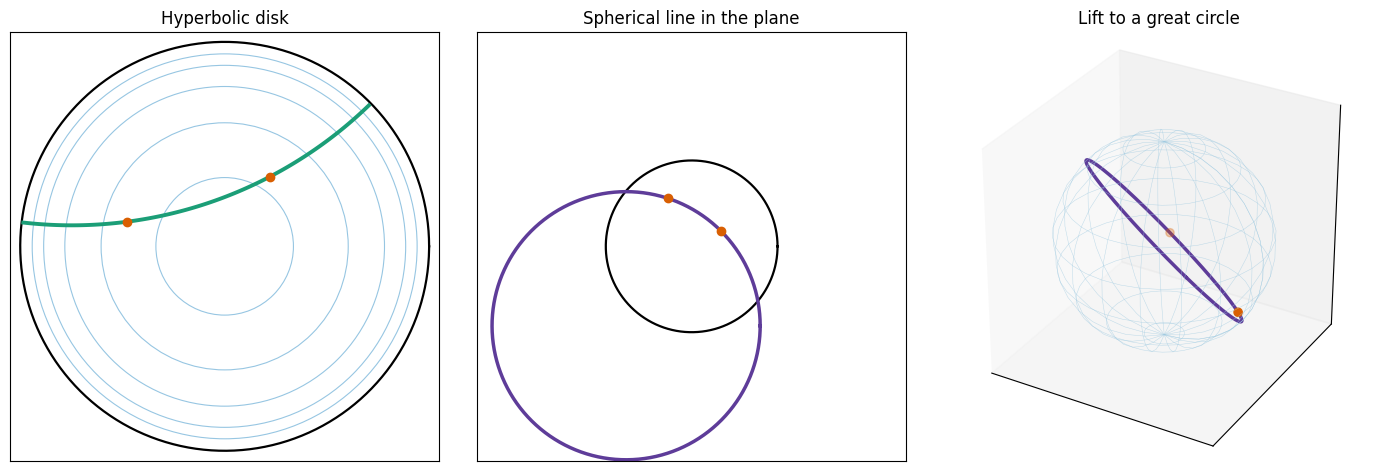

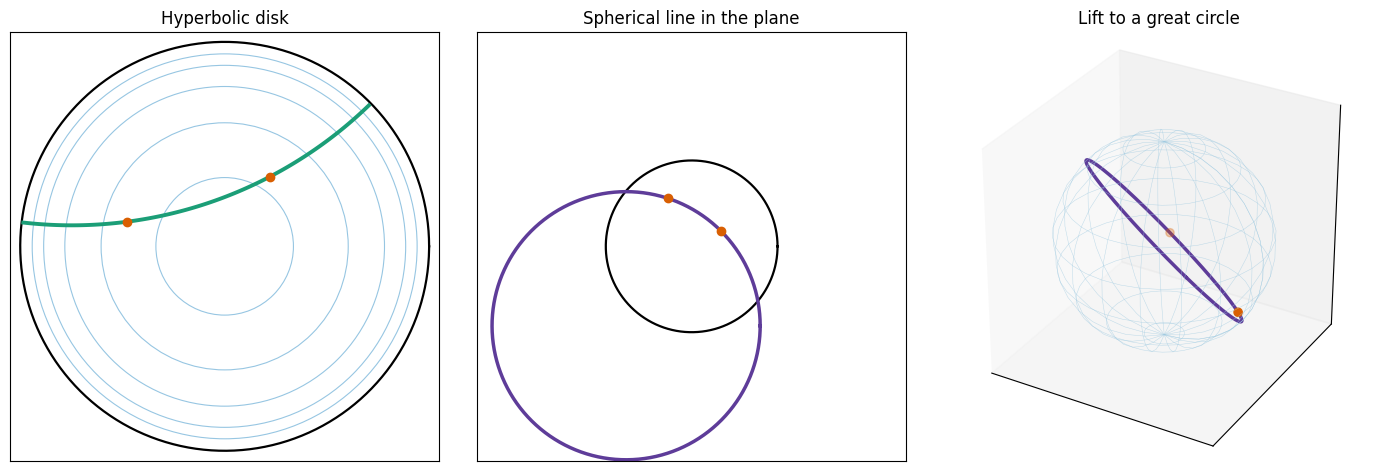

In [13]:
h_a = np.array([0.22, 0.34])
h_b = np.array([-0.48, 0.12])
h_circle = poincare_geodesic_circle(h_a, h_b)
assert h_circle is not None
h_arc = circle_arc_inside_disk(h_circle, samples=900)

s_a = np.array([0.34, 0.18])
s_b = np.array([-0.28, 0.56])
s_circle = spherical_geodesic_circle(s_a, s_b)
assert s_circle is not None
s_plane_circle = s_circle.sample(720)
sphere_great_circle = inverse_stereographic(s_plane_circle)
unit_circle = Circle2D(np.array([0.0, 0.0]), 1.0).sample(500)

fig_models = plt.figure(figsize=(14, 4.6), constrained_layout=True)
ax_h = fig_models.add_subplot(1, 3, 1)
ax_s = fig_models.add_subplot(1, 3, 2)
ax_3 = fig_models.add_subplot(1, 3, 3, projection="3d")

ax_h.plot(unit_circle[:, 0], unit_circle[:, 1], color="black", lw=1.6)
ax_h.plot(h_arc[:, 0], h_arc[:, 1], color="#1b9e77", lw=2.8)
ax_h.scatter([h_a[0], h_b[0]], [h_a[1], h_b[1]], color="#d95f02", zorder=5)
for distance in [0.7, 1.4, 2.1, 2.8, 3.5]:
    r = np.tanh(0.5 * distance)
    ax_h.add_patch(plt.Circle((0, 0), r, fill=False, lw=0.8, color="#6baed6", alpha=0.7))
ax_h.set_title("Hyperbolic disk")
ax_h.set_aspect("equal")
ax_h.set_xlim(-1.05, 1.05)
ax_h.set_ylim(-1.05, 1.05)
ax_h.set_xticks([])
ax_h.set_yticks([])

ax_s.plot(unit_circle[:, 0], unit_circle[:, 1], color="black", lw=1.6)
ax_s.plot(s_plane_circle[:, 0], s_plane_circle[:, 1], color="#5e3c99", lw=2.5)
ax_s.scatter([s_a[0], s_b[0]], [s_a[1], s_b[1]], color="#d95f02", zorder=5)
ax_s.set_title("Spherical line in the plane")
ax_s.set_aspect("equal")
ax_s.set_xlim(-2.5, 2.5)
ax_s.set_ylim(-2.5, 2.5)
ax_s.set_xticks([])
ax_s.set_yticks([])

sx, sy, sz = sphere_mesh(36, 18)
ax_3.plot_wireframe(sx, sy, sz, rstride=2, cstride=2, linewidth=0.35, color="#9ecae1", alpha=0.65)
ax_3.plot(sphere_great_circle[:, 0], sphere_great_circle[:, 1], sphere_great_circle[:, 2], color="#5e3c99", lw=2.5)
points_on_sphere = inverse_stereographic(np.vstack([s_a, s_b]))
ax_3.scatter(points_on_sphere[:, 0], points_on_sphere[:, 1], points_on_sphere[:, 2], color="#d95f02", s=35)
ax_3.set_title("Lift to a great circle")
ax_3.set_box_aspect((1, 1, 1))
ax_3.set_xticks([])
ax_3.set_yticks([])
ax_3.set_zticks([])

artifact_paths["non_euclidean_models"] = Path("artifacts/chapter-16/plots/non-euclidean-models.png")
fig_models.savefig(PROJECT_ROOT / artifact_paths["non_euclidean_models"], dpi=170)
fig_models


In [14]:
orthogonality_residual = abs(np.dot(h_circle.center, h_circle.center) - h_circle.radius**2 - 1.0)
antipodal_residual = abs(s_circle.radius**2 - np.dot(s_circle.center, s_circle.center) - 1.0)
radial_distances = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
radial_points = poincare_radial_points(radial_distances, angle=np.deg2rad(20.0))
recovered_distances = np.array([poincare_distance([0.0, 0.0], p) for p in radial_points])

print("Hyperbolic geodesic orthogonality residual:", orthogonality_residual)
print("Spherical geodesic antipodal-intersection residual:", antipodal_residual)
print("Target hyperbolic radial distances:", radial_distances)
print("Recovered hyperbolic radial distances:", recovered_distances)

assert orthogonality_residual < 1e-12
assert antipodal_residual < 1e-12
assert np.allclose(radial_distances, recovered_distances, atol=1e-12)


Hyperbolic geodesic orthogonality residual: 0.0
Spherical geodesic antipodal-intersection residual: 0.0
Target hyperbolic radial distances: [0.5 1.  1.5 2.  2.5]
Recovered hyperbolic radial distances: [0.5 1.  1.5 2.  2.5]


## Final Sanity Pass

A computational chapter should be able to audit its own claims. The final cell reruns compact helper-module checks, writes a small JSON record, and asserts that every promised artifact exists under `artifacts/chapter-16`. The thresholds are tight where the calculation is exact up to floating-point roundoff. The loxodrome bearing check is looser because it uses sampled finite differences on a curve.


In [15]:
checks = sanity_checks()
for key, value in checks.items():
    print(f"{key:36s} {value:.6e}")

assert checks["point_null_residual"] < 1e-12
assert checks["distance_identity_residual"] < 1e-12
assert checks["translation_metric_error"] < 1e-12
assert checks["scaling_metric_error"] < 1e-12
assert checks["inversion_involution_error"] < 1e-12
assert checks["inverted_line_circle_residual"] < 1e-10
assert checks["transversion_inverse_error"] < 1e-12
assert checks["similarity_noncommutativity_norm"] > 1e-3
assert checks["loxodrome_bearing_std"] < 0.003
assert checks["hyperbolic_orthogonality_residual"] < 1e-12
assert checks["spherical_antipodal_residual"] < 1e-12
assert checks["torus_orbit_residual"] < 1e-12

artifact_paths["sanity_results"] = Path("artifacts/chapter-16/data/sanity-results.json")
with (PROJECT_ROOT / artifact_paths["sanity_results"]).open("w", encoding="utf-8") as f:
    json.dump({"source_span": source_span, "checks": checks}, f, indent=2, sort_keys=True)

for name, relative_path in artifact_paths.items():
    path = PROJECT_ROOT / relative_path
    print(f"{name:24s} -> {relative_path} ({path.stat().st_size:,} bytes)")
    assert path.exists() and path.stat().st_size > 0


point_null_residual                  0.000000e+00
distance_identity_residual           0.000000e+00
translation_metric_error             0.000000e+00
scaling_metric_error                 0.000000e+00
inversion_involution_error           5.551115e-17
inverted_line_circle_residual        8.881784e-16
transversion_inverse_error           1.110223e-16
similarity_noncommutativity_norm     5.422177e-01
loxodrome_bearing_std                7.970359e-04
hyperbolic_orthogonality_residual    0.000000e+00
spherical_antipodal_residual         0.000000e+00
torus_orbit_residual                 1.387779e-16
inversion_grid           -> artifacts\chapter-16\plots\inversion-grid.html (5,062,659 bytes)
noncommutativity         -> artifacts\chapter-16\plots\scaling-translation-noncommutativity.html (4,855,409 bytes)
transversion             -> artifacts\chapter-16\plots\transversion-grid.html (5,040,523 bytes)
loxodrome                -> artifacts\chapter-16\plots\loxodrome-sphere.html (5,019,543 bytes)
s

## Chapter Takeaways

Sphere reflection is inversion. It is an involution, it maps radial distances reciprocally relative to the mirror radius, and its derivative is a scalar times a reflection. That is why it bends lines into circles while preserving local angles.

Scaling is a conformal rotor-style operation, not just an affine convenience. In the point embedding, it works by changing the null-coordinate weight and then recovering finite coordinates. Translation and scaling do not commute; the missing commutation is the visible sign that the center and order of an operator product matter.

General conformal operators create orbits that are richer than Euclidean rigid-motion orbits. Logarithmic spirals lift to loxodromes. Repeated similarities generate shell-like trails. Circular orbits sweep tori. The same operator-first mindset also explains the hyperbolic and spherical readings: choose a different vector to behave like infinity, and the conformal model starts describing a different geometry without changing the broad algebraic language.
